# Agent Frameworks - Microsoft Agent Framework Additional Lab
The code on this lab proposes a multi-step orchestration pipeline powered by a local LLM (Ollama running Qwen 2.5). The goal is to ingest an initial product prompt, dynamically generate a marketing tagline, translate it into Spanish, pause execution for a human confirmation step, and conditionally write the final output to the local file system using the Model Context Protocol (MCP).

## A graph-based **workflow engine** with human-in-the-loop approval
The `workflow_app.py` builds a small **multi-agent pipeline** using Microsoft's `agent_framework`, running against a local **Ollama** model (`qwen2.5:7b`):
1. **WriterAgent** — generates a one-sentence product tagline for a prompt ("A high-performance organic energy drink for programmers").
2. **TranslatorAgent** — translates that tagline into Spanish.
3. **HumanDecisionInterrupter** — shows the translated text and asks the user (via terminal `input()`) whether to save it to disk.
4. **WorkflowRouter** — branches on that y/n answer, routing to either `save` or `skip`.
5. **FileSaver** *(save branch only)* — writes the text to `maf_translate.txt` via an MCP filesystem server (`@modelcontextprotocol/server-filesystem`), with a manual-write fallback if the MCP call fails.
6. **FinalFormatter** — the terminal node; formats whatever text survived (saved or original) into a final uppercase "BRAND OUTPUT" string and yields it as the workflow's output.

The graph is wired with `WorkflowBuilder`, using conditional edges (`should_save`/`should_skip`) out of the router, and both branches converge back on the formatter.

### 1. Infrastructure & Workspace Setup
* Workspace Isolation: Resolves and safely creates a designated ./workspace/ directory for secure file storage.
* MCP Integration: Dynamically instantiates a Model Context Protocol tool wrapper (FilesystemMCP) using Node's npx @modelcontextprotocol/server-filesystem package to handle sandboxed disk operations.

### 2. Observability & Logging Middleware
* notebook_chat_logger: An agent-level middleware intercepting workflow steps to clearly print the incoming user prompts and outgoing text responses.
* notebook_tool_logger: A function-level middleware logging the specific arguments and execution results of executed tools.

### 3. Agent Capabilities (Worker Layer)
* WriterAgent: Instructed to generate a precise, one-sentence product tagline without quotation marks.
* TranslatorAgent: Instructed to take text inputs and translate them exactly into natural, raw Spanish.

### 4. Type-Annotated Workflow Executions (Node Layer)
* HumanDecisionInterrupter: Extracts the generated translation, previews it in the console, breaks processing to wait for an interactive input() loop from the user, and bundles the decision payload.
* WorkflowRouter: Caches state data and acts as a switch gate, emitting "save" or "skip" instructions depending on the human approval step.
* FileSaver: Attempts to utilize the MCP filesystem protocol natively to write the Spanish tagline to maf_translate.txt. Includes a robust fallback to basic Python pathlib writes if the server connection drops.
* FinalFormatter: Acts as a terminal Never outgoing message node that transforms the final string to uppercase text inside a specific banner block (*** BRAND OUTPUT ***).

### 5. Graph Topology (The Blueprint)
The graph connects your steps using targeted execution edges and logic checks (should_save, should_skip):
* If human types "y / yes": -> FileSaver (MCP) -> FinalFormatter
* If human types "n / no": -> FinalFormatter

### Setup

Following the instructions in the ["Day 2: AWS Strands Lab Notebook"](../../2_strands_pydantic/strands_lab.ipynb).

If you want to see more details on its configuration, take a look at the end section here: ["Appendix - Additional Setup Instructions"](#appendix---additional-setup-instructions)

In [5]:
import os
import asyncio
import subprocess
from pathlib import Path
from typing import Never

from dotenv import load_dotenv
from agent_framework import (
    WorkflowBuilder, WorkflowContext, Executor, AgentExecutor, AgentExecutorResponse, 
    Agent, handler, agent_middleware, function_middleware, MCPStdioTool
)
from agent_framework.openai import OpenAIChatCompletionClient

# Load environment configuration variables
load_dotenv(override=True)

# -------------------------------------------------------------------
# Establish target workspace directory structure for local file extraction
workspace = Path("workspace").resolve()
workspace.mkdir(exist_ok=True)

class FilesystemMCP(MCPStdioTool):
    """
    Custom Model Context Protocol (MCP) tool wrapper handling stdio client setup.
    
    Spawns an asynchronous connection to the external file system server 
    and sets the persistent working directory boundary to the resolved workspace.
    """
    def get_mcp_client(self):
        from mcp.client.stdio import StdioServerParameters, stdio_client
        params = StdioServerParameters(command=self.command, args=self.args, env=self.env, cwd=str(workspace))
        return stdio_client(server=params, errlog=subprocess.DEVNULL)

# Instantiate the standard filesystem server definition targeting Node Package Execute
filesystem = FilesystemMCP(
    name="filesystem",
    command="npx",
    args=["-y", "@modelcontextprotocol/server-filesystem", str(workspace)],
)

# -------------------------------------------------------------------
# Observability Middleware Definition
@agent_middleware
async def notebook_chat_logger(context, next):
    """
    Intercepts and logs text communication states across active AI Agent operations.
    
    Prints initial initialization frames, parses recent inbound historical prompt text, 
    and prints out agent generation metrics upon downstream step finalization.
    """
    print(f"\n🚀 [AGENT INITIALIZED] Running task invocation...")
    if hasattr(context, 'messages') and context.messages:
        latest_msg = context.messages[-1]
        msg_text = getattr(latest_msg, 'text', None) or str(latest_msg)
        print(f"📥 [LATEST INPUT]: {msg_text}")
    await next()
    if hasattr(context, 'result') and context.result:
        result_text = getattr(context.result, 'text', None) or str(context.result)
        print(f"📤 [AGENT RESPONSE]: {result_text}")

@function_middleware
async def notebook_tool_logger(context, next):
    """
    Monitors, logs, and formats runtime information for external tool invocations.
    
    Intercepts function parameters before processing and slices oversized downstream 
    response data blocks to ensure optimal console readability.
    """
    print(f"\n🔧 [TOOL CALL] invoking: '{context.function.name}'")
    if hasattr(context, 'arguments') and context.arguments:
        print(f"   ↳ Arguments: {context.arguments}")
    await next()
    if hasattr(context, 'result') and context.result:
        print(f"   ✅ Result: {str(context.result)[:150]}...")

# -------------------------------------------------------------------
# Configure local inference endpoint client mapping to an OpenAI-compatible spec
ollama_client = OpenAIChatCompletionClient(
    model="qwen2.5:7b",
    base_url=os.getenv("OLLAMA_API_BASE", "http://localhost:11434/v1"),
    api_key="Ollama"
)

# -------------------------------------------------------------------
# Marketing agent specialized in short-form creative brand taglines
writer_agent = Agent(
    client=ollama_client,
    instructions="You are a professional creative marketer. Write a concise, 1-sentence product tagline. Do not use quotation marks.",
    name="WriterAgent",
    middleware=[notebook_chat_logger, notebook_tool_logger]
)

# -------------------------------------------------------------------
# Translation agent specialized in converting localized copy directly into Spanish
translator_agent = Agent(
    client=ollama_client,
    instructions="You are an expert translator. Translate the given text exactly into natural Spanish. Return only the final Spanish text.",
    name="TranslatorAgent",
    middleware=[notebook_chat_logger, notebook_tool_logger]
)

# -------------------------------------------------------------------
# TYPE-ANNOTATED ROUTER & INPUT INTERACTION NODES
#
# All four custom executors below use WorkflowContext[T] / WorkflowContext[T, U] generics on `ctx`, and send their outgoing 
# payload via ctx.send_message(...) (or ctx.yield_output(...) for the terminal node) rather than a bare `return`.
# This is what the framework's output validator inspects to know what each executor is allowed to produce - a bare `WorkflowContext` 
# (no brackets) or a handler that only `return`s a value will fail validation for output/intermediate executors.
# -------------------------------------------------------------------

class HumanDecisionInterrupter(Executor):
    """
    Workflow executor that pauses execution to secure manual user consensus.
    
    Safely unpacks varying agent responses, falls back to a structural default 
    on empty generation buffers, and forwards an interactive command choice map.
    """
    @handler
    async def ask_user(self, response: AgentExecutorResponse, ctx: WorkflowContext[dict]) -> None:
        extracted_text = ""
        if hasattr(response, "agent_response") and response.agent_response:
            extracted_text = getattr(response.agent_response, "text", "")
        elif hasattr(response, "agent_run_response") and response.agent_run_response:
            extracted_text = getattr(response.agent_run_response, "text", "")
        else:
            extracted_text = str(response)

        extracted_text = extracted_text.strip()
        if not extracted_text:
            extracted_text = "Una bebida energética orgánica de alto rendimiento para programadores."
            print("\n⚠️ Warning: The translator agent returned an empty response. Using pre-baked fallback string.")

        print(f"\n🔍 [TRANSLATION PREVIEW]:\n{extracted_text}")

        user_choice = input("💾 Would you like to save this translation to a file? (y/n): ").strip().lower()
        await ctx.send_message({"choice": user_choice, "text": extracted_text})


class WorkflowRouter(Executor):
    """
    Evaluates runtime states and assigns next-hop edge targets inside the workflow.
    
    Saves context string records into the global graph state mapping table 
    and publishes text flags evaluated by graph routing conditions.
    """
    @handler
    async def route_decision(self, data: dict, ctx: WorkflowContext[str]) -> None:
        ctx.set_state("saved_text", data.get("text", ""))
        decision = "save" if data.get("choice") in ["y", "yes"] else "skip"
        await ctx.send_message(decision)


class FileSaver(Executor):
    """
    Handles workflow pipeline persistence using standard context tool wrappers.
    
    Provides reliable, self-healing file creation by cascading from managed 
    MCP runtime client executions straight into native filesystem streams.
    """
    def __init__(self, filesystem_tool, **kwargs):
        super().__init__(**kwargs)
        self.fs = filesystem_tool

    @handler
    async def save_to_disk(self, data: str, ctx: WorkflowContext[str]) -> None:
        text_to_save = ctx.get_state("saved_text", "")
        print("\n🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...")

        try:
            result = await self.fs.call_tool(
                "write_file",
                path="maf_translate.txt",
                content=text_to_save,
            )
            print(f"✨ SUCCESS: MCP tool written to maf_translate.txt via tool lifecycle wrapper.")
            print(f"🔍 DEBUG: MCP result = {result!r}")
        except Exception as e:
            print(f"⚠️ Direct MCP method call failed ({e}). Falling back to manual write...")
            file_path = workspace / "maf_translate.txt"
            file_path.write_text(text_to_save, encoding="utf-8")
            print(f"✨ Fallback SUCCESS: File created at {file_path.resolve()}")

        await ctx.send_message(text_to_save)


class FinalFormatter(Executor):
    """
    The terminal node of the workflow graph that outputs the final brand presentation.
    
    Uses `Never` for outbound messages and yields a stylized, capitalized string 
    via `ctx.yield_output` to satisfy the framework's output validator requirements.
    """
    @handler
    async def format_output(self, response: str, ctx: WorkflowContext[Never, str]) -> None:
        text_to_format = ctx.get_state("saved_text", "")

        val = getattr(response, "value", response)
        if hasattr(val, "result"):
            val = val.result

        if str(val) not in ("skip", "save") and len(str(val)) > 5:
            text_to_format = str(val)

        final_string = f"*** BRAND OUTPUT ***\n{text_to_format.upper()}"
        await ctx.yield_output(final_string)

# -------------------------------------------------------------------
# COMPOSE THE GRAPH VIA STANDARD CONDITIONAL EDGES
writer_node = AgentExecutor(agent=writer_agent, id="writer_step")
translator_node = AgentExecutor(agent=translator_agent, id="translator_step")
interrupter_node = HumanDecisionInterrupter(id="interrupter_step")
router_node = WorkflowRouter(id="router_step")
saver_node = FileSaver(filesystem_tool=filesystem, id="saver_step")
formatter_node = FinalFormatter(id="formatter_step")

def should_save(edge_context) -> bool:
    """
    Returns True if the upstream router yielded a confirmation to save data.
    """
    val = getattr(edge_context, "value", edge_context)
    if hasattr(val, "result"): 
        val = val.result
    return "save" in str(val).lower()

def should_skip(edge_context) -> bool:
    """
    Returns True if the upstream router yielded a confirmation to skip saving.
    """
    val = getattr(edge_context, "value", edge_context)
    if hasattr(val, "result"): 
        val = val.result
    return "skip" in str(val).lower()

# -------------------------------------------------------------------
# Workflow Build
workflow = (
    WorkflowBuilder(start_executor=writer_node, output_from=[formatter_node])
    .add_edge(writer_node, translator_node)
    .add_edge(translator_node, interrupter_node)
    .add_edge(interrupter_node, router_node)
    
    .add_edge(router_node, saver_node, condition=should_save)
    .add_edge(saver_node, formatter_node)
    
    .add_edge(router_node, formatter_node, condition=should_skip)
    .build()
)

# -------------------------------------------------------------------
# Workflow Execution
async def main():
    print("🎬 Starting multi-agent Ollama Workflow...")
    
    async with filesystem:
        result = await workflow.run("A high-performance organic energy drink for programmers.")
    
    print("\n🏁 [WORKFLOW EXECUTION COMPLETE]")
    outputs = result.get_outputs()
    if outputs:
        print(outputs[-1])
    else:
        print("No output generated:", result)

await main()

🎬 Starting multi-agent Ollama Workflow...

🚀 [AGENT INITIALIZED] Running task invocation...
📥 [LATEST INPUT]: A high-performance organic energy drink for programmers.
📤 [AGENT RESPONSE]: Fuel your coding sessions with pure performance.

🚀 [AGENT INITIALIZED] Running task invocation...
📥 [LATEST INPUT]: Fuel your coding sessions with pure performance.
📤 [AGENT RESPONSE]:  Un refresco orgánico de alta energía para programadores.

🔍 [TRANSLATION PREVIEW]:
Un refresco orgánico de alta energía para programadores.

🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...
✨ SUCCESS: MCP tool written to maf_translate.txt via tool lifecycle wrapper.
🔍 DEBUG: MCP result = [<agent_framework._types.Content object at 0x113702960>, <agent_framework._types.Content object at 0x10acd5f40>]

🏁 [WORKFLOW EXECUTION COMPLETE]
*** BRAND OUTPUT ***
UN REFRESCO ORGÁNICO DE ALTA ENERGÍA PARA PROGRAMADORES.


### agent_framework ships a built-in WorkflowViz class for presnt the final workflow diagram

In [20]:
from agent_framework import WorkflowViz

viz = WorkflowViz(workflow)
print(viz.to_mermaid())

flowchart TD
  writer_step["writer_step (Start)"];
  translator_step["translator_step"];
  interrupter_step["interrupter_step"];
  router_step["router_step"];
  saver_step["saver_step"];
  formatter_step["formatter_step"];
  writer_step --> translator_step;
  translator_step --> interrupter_step;
  interrupter_step --> router_step;
  router_step -. conditional .-> saver_step;
  saver_step --> formatter_step;
  router_step -. conditional .-> formatter_step;


### Image file (PNG/SVG/PDF)

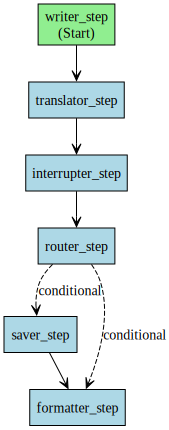

In [25]:
import graphviz
from IPython.display import display

viz = WorkflowViz(workflow)
dot_content = viz.to_digraph()
display(graphviz.Source(dot_content))

### Save it

In [ ]:
path = viz.save_svg("workspace/workflow_graph.svg")   # or save_png / save_pdf
print(f"saved to {path}")

saved to workspace/workflow_graph.svg


## Appendix - Additional Setup Instructions
### Observability
To log the execution inside a Jupyter Notebook using the Microsoft Agent Framework (agent-framework), you can leverage the framework's native Agent Middleware architecture. [1] 

Middleware acts as an execution interceptor, letting you print out exactly what messages are being sent to Groq/LiteLLM, what choices the agent is making, and when tools (like your board functions or the filesystem MCP) are triggered. [2] 

#### Step 1: Define Logging Middleware
Add these two lightweight middleware handlers to intercept both agent chat sequences and specific function/tool executions: [3] 
#### Step 2: Register the Middleware to your Worker
Pass your loggers directly into the Agent definition using the middleware parameter: [4] 

[1] [https://aws.plainenglish.io](https://aws.plainenglish.io/agent-framework-python-overview-b9ef84ac80d9)
[2] [https://www.youtube.com](https://www.youtube.com/watch?v=2IMONMwaVgQ)
[3] [https://microsoft.github.io](https://microsoft.github.io/ai-agents-for-beginners/14-microsoft-agent-framework/)
[4] [https://microsoft-agent-framework.mintlify.app](https://microsoft-agent-framework.mintlify.app/concepts/middleware)


### Alternative: Zero-Code Environment Variables
If you prefer standard OpenTelemetry console streams rather than building python functions, the Microsoft Agent Framework natively integrates with OpenTelemetry. You can toggle it on globally by running this in an upstream notebook cell: [5, 6] 

Once you attach the middleware logging, does your terminal show the model executing plan_steps sequentially, or is your FilesystemMCP tool throwing a node executable path error?

[5] [https://learn.microsoft.com](https://learn.microsoft.com/en-us/agent-framework/agents/observability)
[6] [https://microsoft-agent-framework.mintlify.app](https://microsoft-agent-framework.mintlify.app/concepts/observability)


In [ ]:
import os
import asyncio
from dotenv import load_dotenv
from agent_framework import (WorkflowBuilder, WorkflowContext, Executor, AgentExecutor, AgentExecutorResponse, 
                             Agent, handler, MCPStdioTool, agent_middleware, function_middleware)
from agent_framework.openai import OpenAIChatCompletionClient

load_dotenv(override=True)

# -------------------------------------------------------------------
# Observability Definition
# 1. Clear up the chat logger pipeline invocation
@agent_middleware
async def notebook_chat_logger(context, next):
    print(f"\n🚀 [AGENT INITIALIZED] Running task invocation...")
    
    if hasattr(context, 'messages') and context.messages:
        latest_msg = context.messages[-1]
        msg_text = getattr(latest_msg, 'text', None) or str(latest_msg)
        print(f"📥 [LATEST INPUT]: {msg_text}")
    
    # 🧠 FIX: Change 'next(context)' to 'next()'
    await next()
    
    if hasattr(context, 'result') and context.result:
        result_text = getattr(context.result, 'text', None) or str(context.result)
        print(f"📤 [AGENT RESPONSE]: {result_text}")

# 2. Clear up the function/tool logger pipeline invocation
@function_middleware
async def notebook_tool_logger(context, next):
    print(f"\n🔧 [TOOL CALL] invoking: '{context.function.name}'")
    if hasattr(context, 'arguments') and context.arguments:
        print(f"   ↳ Arguments: {context.arguments}")
        
    # 🧠 FIX: Change 'next(context)' to 'next()'
    await next()
    
    if hasattr(context, 'result') and context.result:
        print(f"   ✅ Result: {str(context.result)[:150]}...")

# -------------------------------------------------------------------
# INITIALIZE THE MODEL CLIENT (OLLAMA TARGET)
ollama_client = OpenAIChatCompletionClient(
    model="qwen2.5:7b",
    base_url=os.getenv("OLLAMA_API_BASE", "http://localhost:11434/v1"),
    api_key="Ollama"
)

# -------------------------------------------------------------------
# DEFINE INDIVIDUAL WORKER AGENTS
writer_agent = Agent(
    client=ollama_client,
    instructions="You are a professional creative marketer. Write a concise, 1-sentence product tagline.",
    name="WriterAgent",
    middleware=[notebook_chat_logger, notebook_tool_logger]
)

translator_agent = Agent(
    client=ollama_client,
    instructions="You are a precise translator. Translate the text given to you into natural Spanish.",
    name="TranslatorAgent",
    middleware=[notebook_chat_logger, notebook_tool_logger]
)

# -------------------------------------------------------------------
# FIXED: CUSTOM TYPE-COMPATIBLE CODE EXECUTOR NODE
class FinalFormatter(Executor):
    @handler
    async def format_output(self, response: AgentExecutorResponse, ctx: WorkflowContext) -> str:
        # 🧠 Extract the generated response string safely from the upstream object wrapper
        # Note:Depending on your minor library revision version, text is stored inside response.agent_response or response.agent_run_response
        extracted_text = ""
        if hasattr(response, "agent_response") and response.agent_response:
            extracted_text = getattr(response.agent_response, "text", "")
        elif hasattr(response, "agent_run_response") and response.agent_run_response:
            extracted_text = getattr(response.agent_run_response, "text", "")
        else:
            extracted_text = str(response)

        final_result = f"*** BRAND OUTPUT ***\n{extracted_text.upper()}"
        return final_result

# -------------------------------------------------------------------
# COMPOSE THE MULTI-AGENT GRAPH VIA WORKFLOWBUILDER
writer_node = AgentExecutor(agent=writer_agent, id="writer_step")
translator_node = AgentExecutor(agent=translator_agent, id="translator_step")
formatter_node = FinalFormatter(id="formatter_step")

# Now the graph compilation passes validation because types align correctly
workflow = (
    WorkflowBuilder(start_executor=writer_node)
    .add_edge(writer_node, translator_node)
    .add_edge(translator_node, formatter_node)
    .build()
)

# -------------------------------------------------------------------
# RUN THE WORKFLOW
async def main():
    print("🎬 Starting multi-agent Ollama Workflow...")
    
    # 🧠 FIX: Pass the input via context_data dictionary mapping or as a pure positional argument
    result = await workflow.run("A high-performance organic energy drink for programmers.")
    
    print("\n🏁 [WORKFLOW EXECUTION COMPLETE]")
    
    # Extract the final formatted text returned by your FinalFormatter node
    outputs = result.get_outputs()
    if outputs:
        print(outputs[0])
    else:
        print("No output generated:", result)

await main()


/var/folders/j9/pgwv4z1143q_6zprltzrvf9w0000gn/T/ipykernel_22657/2130170056.py:95: DeprecationWarning: WorkflowBuilder built without explicit output_from or intermediate_output_from; every yield_output produces type='output' for compatibility. Pass output_from='all', output_from=[...], or intermediate_output_from=[...] to opt into explicit designation - explicit designation will be required in a future version.
  .build()


🎬 Starting multi-agent Ollama Workflow...

🚀 [AGENT INITIALIZED] Running task invocation...
📥 [LATEST INPUT]: A high-performance organic energy drink for programmers.
📤 [AGENT RESPONSE]: Fuel your code with nature's power."

🚀 [AGENT INITIALIZED] Running task invocation...
📥 [LATEST INPUT]: Fuel your code with nature's power."
📤 [AGENT RESPONSE]:  Un bebida energética orgánica de alto rendimiento para programadores.

🏁 [WORKFLOW EXECUTION COMPLETE]
Fuel your code with nature's power."
